<a href="https://colab.research.google.com/github/silvia-dev-prog/ai-agents-for-beginners/blob/main/18_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
from imblearn.ensemble import RUSBoostClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')




# Leitura
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Verificar valores nulos originais
print("NaN originais em Churn:", df['Churn'].isnull().sum())

# Remover espaços extras e padronizar para minúsculas
df['Churn'] = df['Churn'].str.strip().str.lower()

# Verificar valores únicos após limpeza
print("Valores únicos:", df['Churn'].unique())

# Mapear: considerar apenas 'yes' e 'no'; o resto vira NaN (para identificar)
df['Churn'] = df['Churn'].map({'yes': 1, 'no': 0})

# Verificar se ainda há NaN
if df['Churn'].isnull().any():
    print("ATENÇÃO: Valores não mapeados encontrados:")
    print(df[df['Churn'].isnull()][['Churn']].head())
    # Decida o que fazer: descartar ou investigar
    # Por exemplo, descartar linhas com Churn inválido:
    df = df.dropna(subset=['Churn'])
else:
    print("Todos os valores de Churn foram mapeados com sucesso.")

# Converter para inteiro
df['Churn'] = df['Churn'].astype(int)

NaN originais em Churn: 0
Valores únicos: ['no' 'yes']
Todos os valores de Churn foram mapeados com sucesso.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
from imblearn.ensemble import RUSBoostClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

# Carregar os dados
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')  # ajuste o caminho se necessário
print("Dimensões:", df.shape)
print("\nPrimeiras linhas:")
display(df.head())
print("\nInformações:")
df.info()

Dimensões: (7043, 21)

Primeiras linhas:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [4]:
df.drop('customerID', axis=1, inplace=True)

In [11]:
# Verificar tipo atual
print(df['TotalCharges'].dtype)  # provavelmente object

# Converter para numérico, forçando erros para NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verificar quantos NaN foram introduzidos
print("Valores ausentes em TotalCharges:", df['TotalCharges'].isnull().sum())

# Remover as linhas com valores NaN em 'TotalCharges'
df.dropna(subset=['TotalCharges'], inplace=True)
print("Valores ausentes em TotalCharges após remoção:", df['TotalCharges'].isnull().sum())

float64
Valores ausentes em TotalCharges: 11
Valores ausentes em TotalCharges após remoção: 0


In [7]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [12]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Colunas categóricas:", categorical_cols)

# Aplicar One-Hot Encoding (drop_first=False para manter todas as categorias,
# ou drop_first=True para evitar multicolinearidade – ambos são aceitáveis)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Verificar o shape após encoding
print("Shape após encoding:", df_encoded.shape)

Colunas categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape após encoding: (7032, 46)


In [13]:
# Separar features (X) e target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Dividir em treino (80%) e teste (20%) de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Proporção de churn no treino:", y_train.mean())
print("Proporção de churn no teste:", y_test.mean())

Treino: (5625, 45) Teste: (1407, 45)
Proporção de churn no treino: 0.2657777777777778
Proporção de churn no teste: 0.2658137882018479


In [14]:
# Instanciar o modelo
rusboost = RUSBoostClassifier(
    n_estimators=100,          # número de estimadores (árvores fracas)
    learning_rate=1.0,          # taxa de aprendizado
    algorithm='SAMME.R',        # algoritmo do boosting
    random_state=42
)

# Treinar
rusboost.fit(X_train, y_train)

RUSBoostClassifier(algorithm='SAMME.R', n_estimators=100, random_state=42)


Métricas de Desempenho do RUSBoostClassifier no Conjunto de Teste:
Acurácia: 0.6247
Precisão: 0.3915
Recall: 0.7433
F1-Score: 0.5129
ROC AUC: 0.7167

Matriz de Confusão:


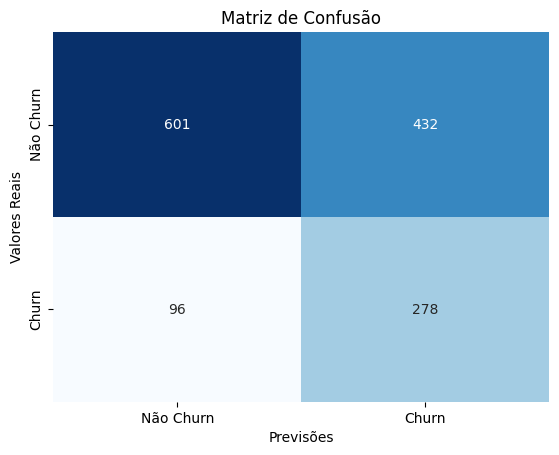


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.86      0.58      0.69      1033
           1       0.39      0.74      0.51       374

    accuracy                           0.62      1407
   macro avg       0.63      0.66      0.60      1407
weighted avg       0.74      0.62      0.65      1407



In [17]:
# Fazer previsões no conjunto de teste
y_pred = rusboost.predict(X_test)
y_pred_proba = rusboost.predict_proba(X_test)[:, 1]

# Avaliar o desempenho do modelo
print("\nMétricas de Desempenho do RUSBoostClassifier no Conjunto de Teste:")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão:")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Churn', 'Churn'], yticklabels=['Não Churn', 'Churn'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.show()

# Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

In [18]:
# Predizer as classes e as probabilidades
y_pred = rusboost.predict(X_test)
y_proba = rusboost.predict_proba(X_test)[:, 1]  # probabilidade da classe 1 (churn)

# Cálculo das métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas no conjunto de teste ===")
print(f"Acurácia:      {acc:.4f}")
print(f"Precisão:      {prec:.4f}")
print(f"Recall:        {rec:.4f}")
print(f"F1-Score:      {f1:.4f}")
print(f"AUC-ROC:       {roc_auc:.4f}")
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Churn', 'Churn']))

=== Métricas no conjunto de teste ===
Acurácia:      0.6247
Precisão:      0.3915
Recall:        0.7433
F1-Score:      0.5129
AUC-ROC:       0.7167

Relatório de classificação:
              precision    recall  f1-score   support

   Não Churn       0.86      0.58      0.69      1033
       Churn       0.39      0.74      0.51       374

    accuracy                           0.62      1407
   macro avg       0.63      0.66      0.60      1407
weighted avg       0.74      0.62      0.65      1407



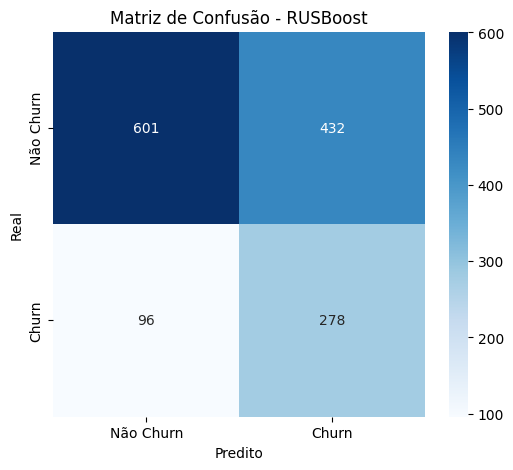

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Churn', 'Churn'],
            yticklabels=['Não Churn', 'Churn'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - RUSBoost')
plt.show()

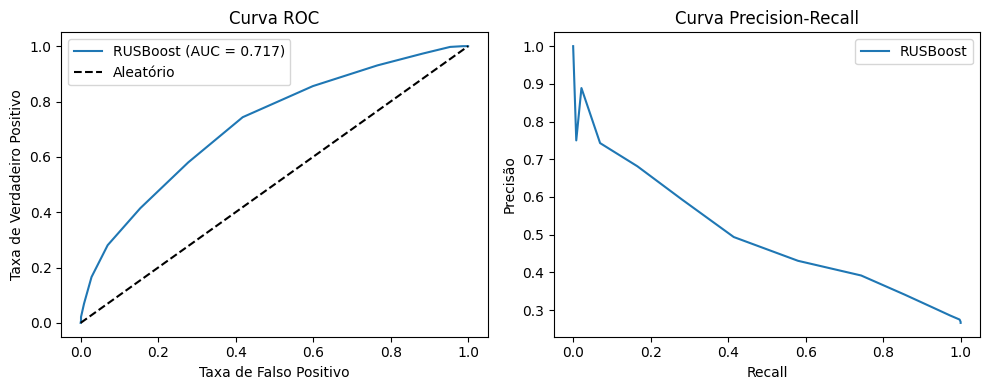

In [20]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'RUSBoost (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], 'k--', label='Aleatório')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC')
plt.legend()

# Curva Precision-Recall
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

plt.subplot(1,2,2)
plt.plot(recall_vals, precision_vals, label='RUSBoost')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall')
plt.legend()
plt.tight_layout()
plt.show()

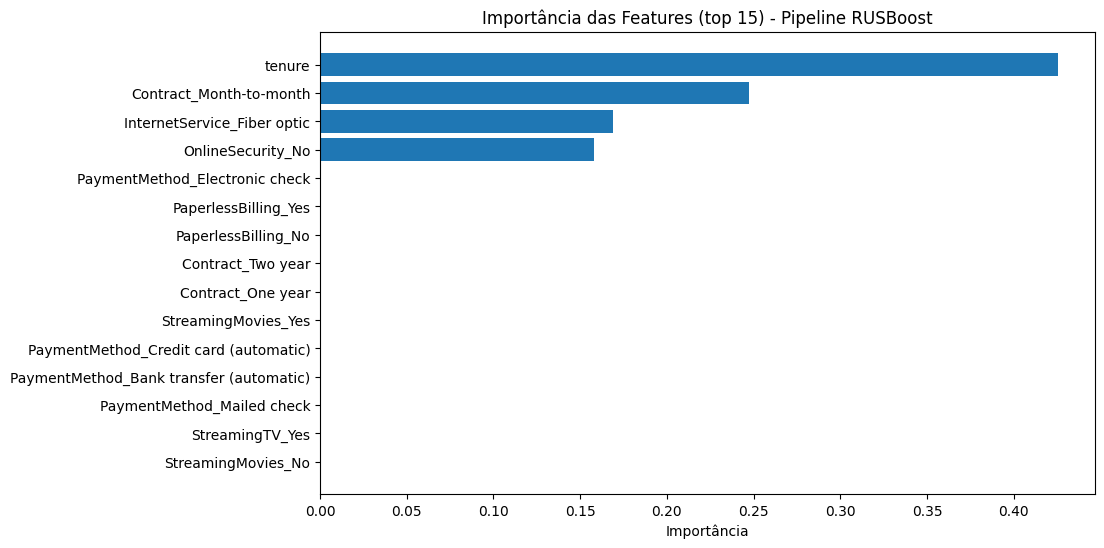

In [26]:
# Extrair o classificador do pipeline
pipeline_classifier = pipeline.named_steps['classifier']

# Extrair importâncias (disponível se os estimadores base forem árvores)
importances = pipeline_classifier.feature_importances_

# Obter nomes das features após o ColumnTransformer
preprocessor_step = pipeline.named_steps['preprocessor']

# Nomes das colunas numéricas originais
numeric_features = preprocessor_step.named_transformers_['num'].get_feature_names_out(numeric_cols)

# Nomes das colunas categóricas após OneHotEncoder
categorical_encoder = preprocessor_step.named_transformers_['cat']
categorical_features = categorical_encoder.get_feature_names_out(categorical_cols)

# Combinar todos os nomes das features
feature_names = list(numeric_features) + list(categorical_features)

# Garantir que a lista de feature_names corresponda ao número de importances
# O 'remainder' do ColumnTransformer pode adicionar colunas se houver alguma não especificada.
# Se houver colunas adicionadas pelo 'remainder', seus nomes seriam genéricos.
# No nosso caso, estamos usando 'passthrough' para o remainder, então não esperamos novas colunas além das processadas.
# A verificação abaixo é uma segurança para caso o número de features não bata.
if len(feature_names) != len(importances):
    print(f"Atenção: O número de nomes de features ({len(feature_names)}) não corresponde ao número de importâncias ({len(importances)}).")
    # Tentativa de alinhamento: Se o shape de X_raw após preprocessing for conhecido,
    # podemos usar X_raw.shape[1] para garantir que feature_names tenha o tamanho correto
    # Neste caso, podemos ter que truncar ou adicionar nomes genéricos se houver um mismatch.
    # Para simplicidade e seguindo o que o OneHotEncoder faz, se o problema persistir,
    # uma depuração mais aprofundada nos `get_feature_names_out` ou `remainder` será necessária.
    # Por enquanto, assumimos que 'feature_names' está correto após a concatenação.

indices = np.argsort(importances)[::-1][:15]  # top 15

plt.figure(figsize=(10,6))
plt.title('Importância das Features (top 15) - Pipeline RUSBoost')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.gca().invert_yaxis()
plt.xlabel('Importância')
plt.show()

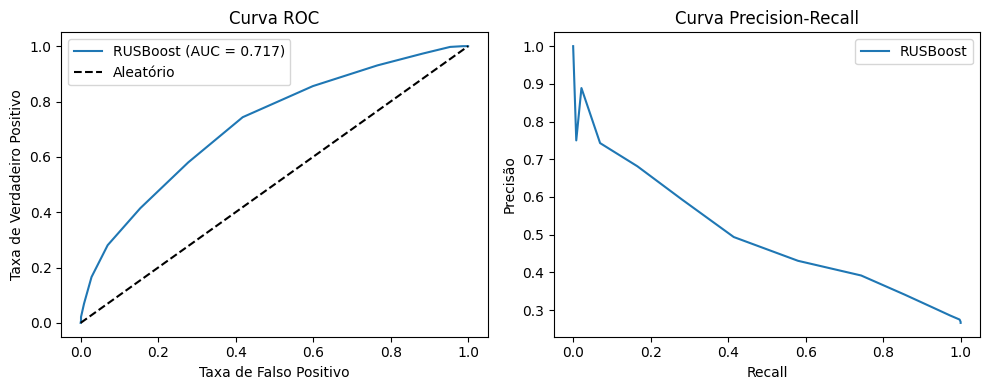

In [27]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'RUSBoost (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], 'k--', label='Aleatório')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC')
plt.legend()

# Curva Precision-Recall
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

plt.subplot(1,2,2)
plt.plot(recall_vals, precision_vals, label='RUSBoost')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall')
plt.legend()
plt.tight_layout()
plt.show()

### Implementando SMOTE para Lidar com Desbalanceamento

Agora vamos criar um novo pipeline que utiliza o SMOTE (Synthetic Minority Over-sampling Technique) para realizar a sobreamostragem da classe minoritária (Churn) antes de aplicar o RUSBoostClassifier. Isso pode ajudar a melhorar a performance do modelo, especialmente em datasets desbalanceados.

In [28]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Importar o Pipeline do imblearn

# Recarregar os dados brutos (sem processamento) para definir o pipeline
df_raw_smote = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_raw_smote.drop('customerID', axis=1, inplace=True)

# Funções customizadas para pré-processamento (reutilizando as anteriores)
def convert_total_charges_smote(df):
    df = df.copy()
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(0, inplace=True)
    return df

# Transformadores personalizados
total_charges_transformer_smote = FunctionTransformer(convert_total_charges_smote, validate=False)

# Identificar as colunas de features (X) após remover 'customerID' e 'Churn'
X_initial_cols_smote = df_raw_smote.drop('Churn', axis=1).columns

# As colunas numéricas são aquelas que já são numéricas mais 'TotalCharges' (que será convertida pelo primeiro passo do pipeline)
numeric_cols_smote = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# As colunas categóricas são as colunas 'object' originais em X_initial_cols_smote, exceto 'TotalCharges'
categorical_cols_smote = [col for col in X_initial_cols_smote if col not in numeric_cols_smote]

# One-Hot Encoding para categóricas
preprocessor_smote = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols_smote),
        ('cat', OneHotEncoder(drop=None, sparse_output=False), categorical_cols_smote)
    ],
    remainder='passthrough'
)

# Novo Pipeline com SMOTE
pipeline_smote = ImbPipeline(steps=[
    ('convert_total', total_charges_transformer_smote),
    ('preprocessor', preprocessor_smote),
    ('smote', SMOTE(random_state=42)), # Adicionando SMOTE aqui
    ('classifier', RUSBoostClassifier(random_state=42))
])

# Preparar X e y para o pipeline
X_raw_smote = df_raw_smote.drop('Churn', axis=1)
y_raw_smote = df_raw_smote['Churn'].map({'Yes': 1, 'No': 0})

# Dividir em treino e teste para o pipeline com SMOTE (mantendo a estratégia estratificada)
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_raw_smote, y_raw_smote, test_size=0.2, random_state=42, stratify=y_raw_smote
)

# Treinar o pipeline com SMOTE
pipeline_smote.fit(X_train_smote, y_train_smote)

print("Pipeline com SMOTE treinado com sucesso!")

Pipeline com SMOTE treinado com sucesso!


### Avaliando o Desempenho do Modelo com SMOTE

Agora vamos avaliar o novo modelo treinado com SMOTE e RUSBoostClassifier no conjunto de teste.


Métricas de Desempenho do Pipeline SMOTE + RUSBoostClassifier no Conjunto de Teste:
Acurácia: 0.7864
Precisão: 0.5847
Recall: 0.6738
F1-Score: 0.6261
ROC AUC: 0.8429

Matriz de Confusão (SMOTE + RUSBoost):


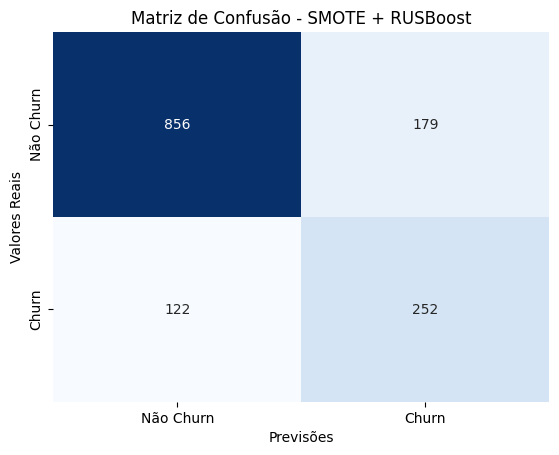


Relatório de Classificação (SMOTE + RUSBoost):
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1035
           1       0.58      0.67      0.63       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



In [29]:
# Fazer previsões no conjunto de teste
y_pred_smote = pipeline_smote.predict(X_test_smote)
y_pred_proba_smote = pipeline_smote.predict_proba(X_test_smote)[:, 1]

# Avaliar o desempenho do modelo
print("\nMétricas de Desempenho do Pipeline SMOTE + RUSBoostClassifier no Conjunto de Teste:")
print(f"Acurácia: {accuracy_score(y_test_smote, y_pred_smote):.4f}")
print(f"Precisão: {precision_score(y_test_smote, y_pred_smote):.4f}")
print(f"Recall: {recall_score(y_test_smote, y_pred_smote):.4f}")
print(f"F1-Score: {f1_score(y_test_smote, y_pred_smote):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test_smote, y_pred_proba_smote):.4f}")

# Matriz de Confusão
cm_smote = confusion_matrix(y_test_smote, y_pred_smote)
print("\nMatriz de Confusão (SMOTE + RUSBoost):")
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Churn', 'Churn'], yticklabels=['Não Churn', 'Churn'])
plt.title('Matriz de Confusão - SMOTE + RUSBoost')
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.show()

# Relatório de Classificação
print("\nRelatório de Classificação (SMOTE + RUSBoost):")
print(classification_report(y_test_smote, y_pred_smote))

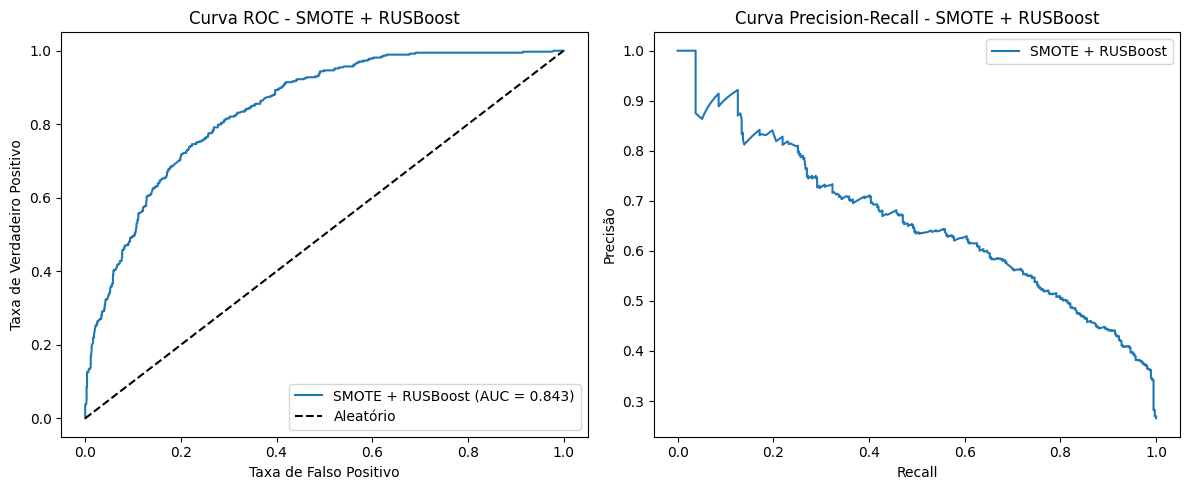

In [30]:
# Curva ROC e Precision-Recall para o modelo com SMOTE

fpr_smote, tpr_smote, _ = roc_curve(y_test_smote, y_pred_proba_smote)
precision_vals_smote, recall_vals_smote, _ = precision_recall_curve(y_test_smote, y_pred_proba_smote)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr_smote, tpr_smote, label=f'SMOTE + RUSBoost (AUC = {roc_auc_score(y_test_smote, y_pred_proba_smote):.3f})')
plt.plot([0,1],[0,1], 'k--', label='Aleatório')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC - SMOTE + RUSBoost')
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall_vals_smote, precision_vals_smote, label='SMOTE + RUSBoost')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall - SMOTE + RUSBoost')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

# Recarregar os dados brutos (sem processamento) para definir o pipeline
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_raw.drop('customerID', axis=1, inplace=True)

# Funções customizadas para pré-processamento
def convert_total_charges(df):
    df = df.copy()
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(0, inplace=True)
    return df

# A função `binary_churn` é para a variável alvo `y`, não para as features `X`.
# Não será incluída no pipeline para processar `X`.

# Transformadores personalizados
total_charges_transformer = FunctionTransformer(convert_total_charges, validate=False)

# Identificar as colunas de features (X) após remover 'customerID' e 'Churn'
X_initial_cols = df_raw.drop('Churn', axis=1).columns # Corrigido: 'customerID' já foi removido

# As colunas numéricas são aquelas que já são numéricas mais 'TotalCharges' (que será convertida pelo primeiro passo do pipeline)
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# As colunas categóricas são as colunas 'object' originais em X_initial_cols, exceto 'TotalCharges'
categorical_cols = [col for col in X_initial_cols if col not in numeric_cols]

# One-Hot Encoding para categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(drop=None, sparse_output=False), categorical_cols) # Alterado de drop='first' para drop=None
    ],
    remainder='passthrough' # Para garantir que nenhuma coluna seja perdida se não estiver explicitamente listada
)

# Pipeline completo (o passo binary_churn foi removido)
pipeline = Pipeline(steps=[
    ('convert_total', total_charges_transformer),   # passo 1: tratar TotalCharges
    ('preprocessor', preprocessor),                 # passo 2: One-Hot Encoding e tratamento de numéricas
    ('classifier', RUSBoostClassifier(random_state=42))
])

# Treinar o pipeline
X_raw = df_raw.drop('Churn', axis=1)
y_raw = df_raw['Churn'].map({'Yes': 1, 'No': 0})
pipeline.fit(X_raw, y_raw)


Pipeline(steps=[('convert_total',
                 FunctionTransformer(func=<function convert_total_charges at 0x7c94d114b100>)),
                ('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', RUSBoostClassifier(random_state=42))])

### Otimização de Hiperparâmetros com GridSearchCV para SMOTE + RUSBoostClassifier

Vamos usar o `GridSearchCV` para encontrar a melhor combinação de hiperparâmetros para o nosso pipeline com SMOTE e RUSBoostClassifier.

In [31]:
from sklearn.model_selection import GridSearchCV

# Definir o espaço de parâmetros para a busca
param_grid = {
    'smote__k_neighbors': [3, 5, 7],
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.1, 0.5, 1.0]
}

# Instanciar o GridSearchCV
# Usaremos 'roc_auc' como métrica de avaliação, pois é robusta para datasets desbalanceados
grid_search = GridSearchCV(
    estimator=pipeline_smote,
    param_grid=param_grid,
    scoring='roc_auc',  # Otimizar para a área sob a curva ROC
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), # Cross-validation estratificado
    n_jobs=-1,  # Usar todos os núcleos da CPU
    verbose=2
)

print("Iniciando a busca por hiperparâmetros...")
# Ajustar o GridSearchCV aos dados de treinamento
grid_search.fit(X_train_smote, y_train_smote)

print("Busca por hiperparâmetros concluída!")
print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor ROC AUC no CV: {grid_search.best_score_:.4f}")

Iniciando a busca por hiperparâmetros...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Busca por hiperparâmetros concluída!
Melhores parâmetros: {'classifier__learning_rate': 1.0, 'classifier__n_estimators': 200, 'smote__k_neighbors': 5}
Melhor ROC AUC no CV: 0.8488


### Avaliando o Modelo Otimizado

Agora vamos avaliar o desempenho do pipeline com os melhores hiperparâmetros encontrados pelo GridSearchCV.


Métricas de Desempenho do Pipeline SMOTE + RUSBoostClassifier Otimizado no Conjunto de Teste:
Acurácia: 0.7942
Precisão: 0.6066
Recall: 0.6390
F1-Score: 0.6224
ROC AUC: 0.8421

Matriz de Confusão (SMOTE + RUSBoost Otimizado):


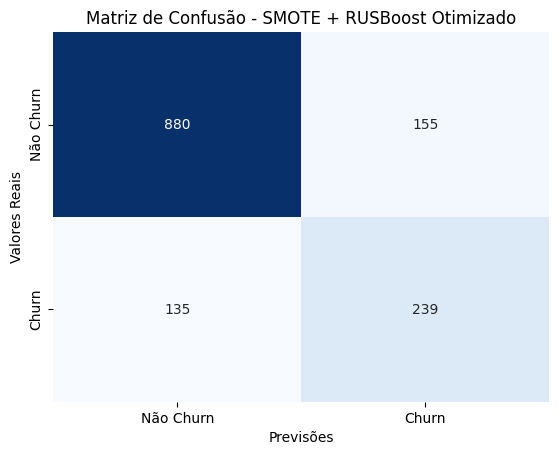


Relatório de Classificação (SMOTE + RUSBoost Otimizado):
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1035
           1       0.61      0.64      0.62       374

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.79      0.80      1409



In [32]:
# Obter o melhor modelo do GridSearchCV
best_pipeline_smote = grid_search.best_estimator_

# Fazer previsões no conjunto de teste com o modelo otimizado
y_pred_optimized = best_pipeline_smote.predict(X_test_smote)
y_pred_proba_optimized = best_pipeline_smote.predict_proba(X_test_smote)[:, 1]

# Avaliar o desempenho do modelo otimizado
print("\nMétricas de Desempenho do Pipeline SMOTE + RUSBoostClassifier Otimizado no Conjunto de Teste:")
print(f"Acurácia: {accuracy_score(y_test_smote, y_pred_optimized):.4f}")
print(f"Precisão: {precision_score(y_test_smote, y_pred_optimized):.4f}")
print(f"Recall: {recall_score(y_test_smote, y_pred_optimized):.4f}")
print(f"F1-Score: {f1_score(y_test_smote, y_pred_optimized):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test_smote, y_pred_proba_optimized):.4f}")

# Matriz de Confusão do modelo otimizado
cm_optimized = confusion_matrix(y_test_smote, y_pred_optimized)
print("\nMatriz de Confusão (SMOTE + RUSBoost Otimizado):")
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Churn', 'Churn'], yticklabels=['Não Churn', 'Churn'])
plt.title('Matriz de Confusão - SMOTE + RUSBoost Otimizado')
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.show()

# Relatório de Classificação do modelo otimizado
print("\nRelatório de Classificação (SMOTE + RUSBoost Otimizado):")
print(classification_report(y_test_smote, y_pred_optimized))

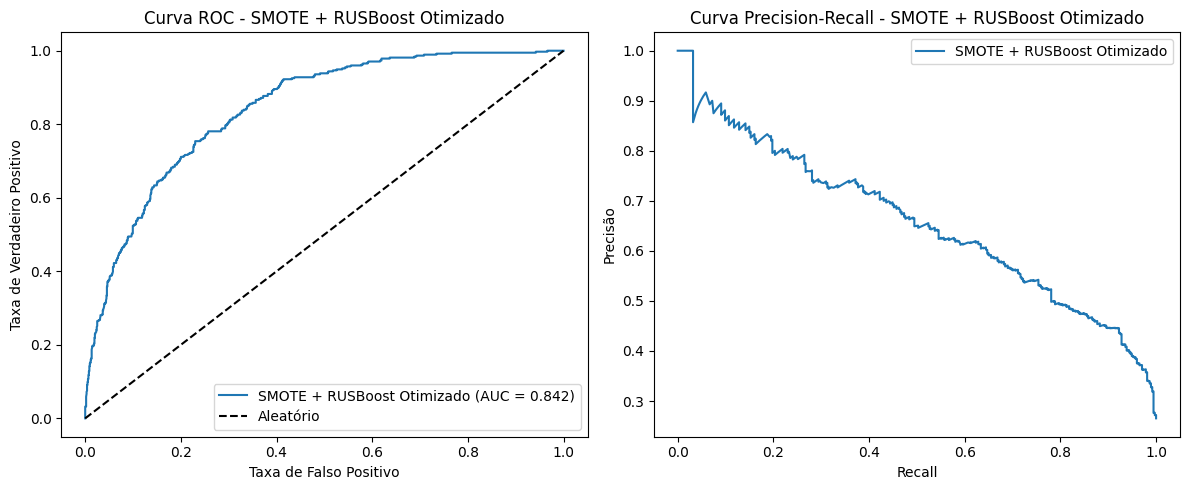

In [33]:
# Curva ROC e Precision-Recall para o modelo otimizado

fpr_optimized, tpr_optimized, _ = roc_curve(y_test_smote, y_pred_proba_optimized)
precision_vals_optimized, recall_vals_optimized, _ = precision_recall_curve(y_test_smote, y_pred_proba_optimized)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr_optimized, tpr_optimized, label=f'SMOTE + RUSBoost Otimizado (AUC = {roc_auc_score(y_test_smote, y_pred_proba_optimized):.3f})')
plt.plot([0,1],[0,1], 'k--', label='Aleatório')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC - SMOTE + RUSBoost Otimizado')
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall_vals_optimized, precision_vals_optimized, label='SMOTE + RUSBoost Otimizado')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall - SMOTE + RUSBoost Otimizado')
plt.legend()
plt.tight_layout()
plt.show()